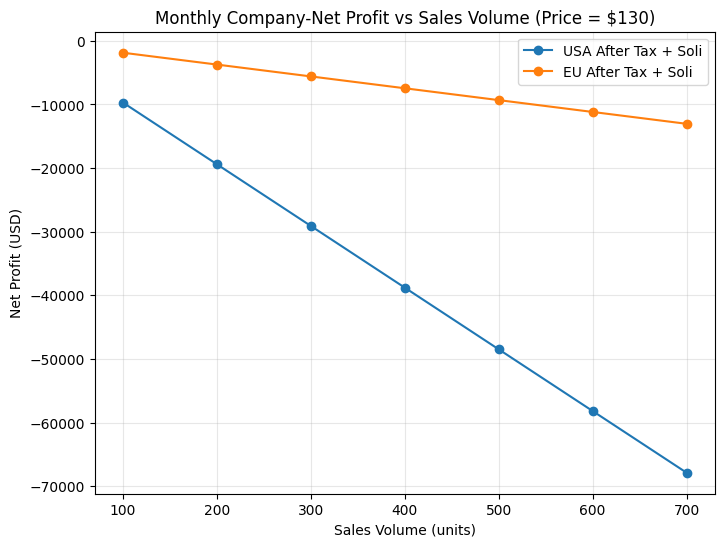

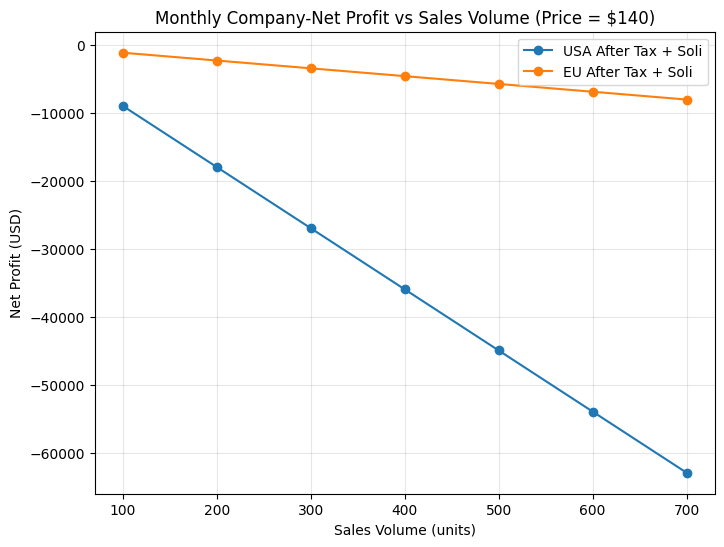

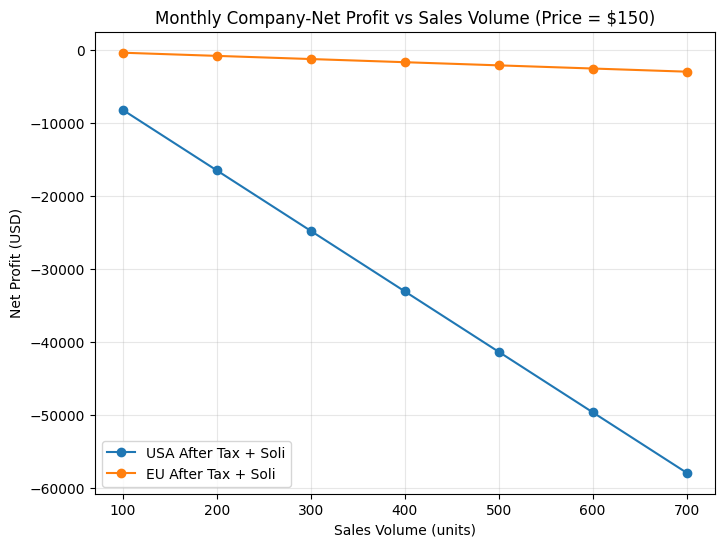

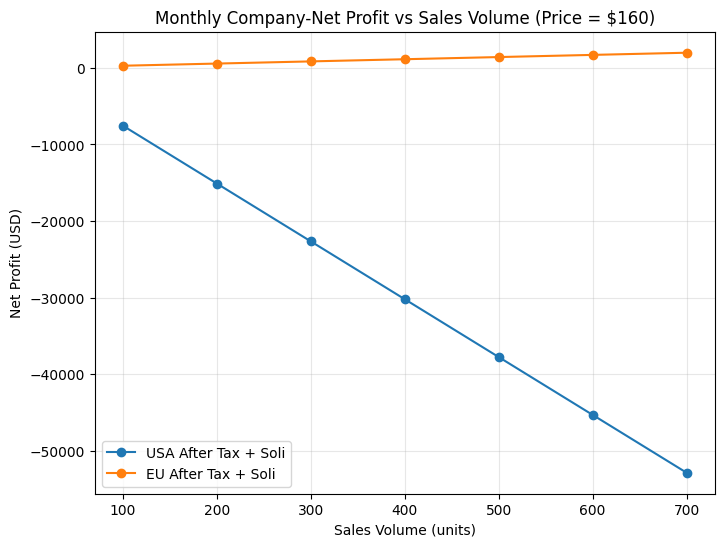

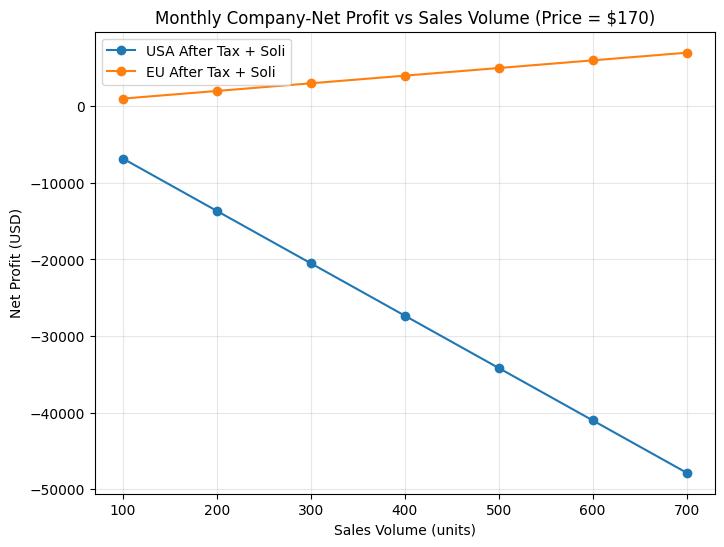

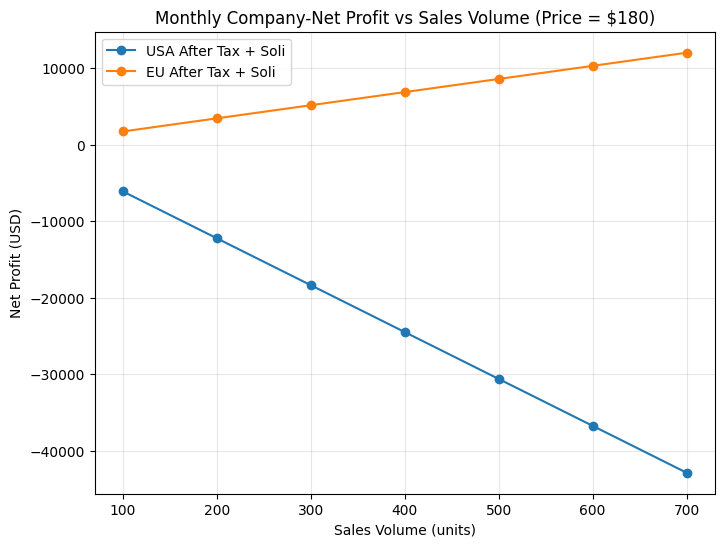

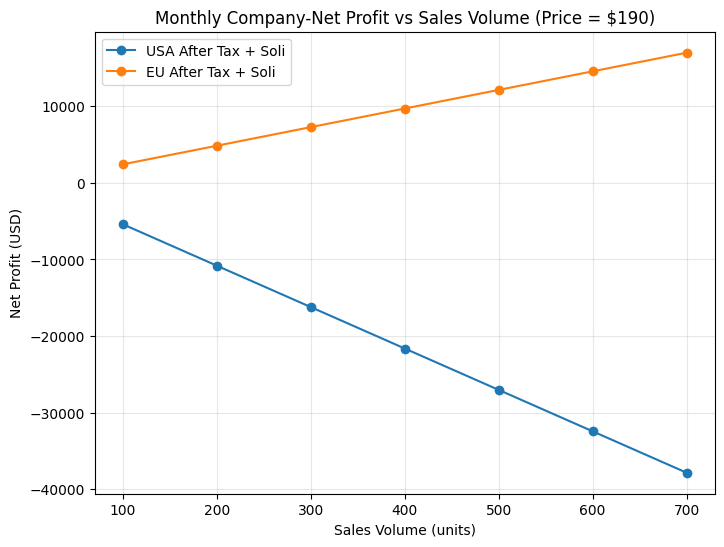

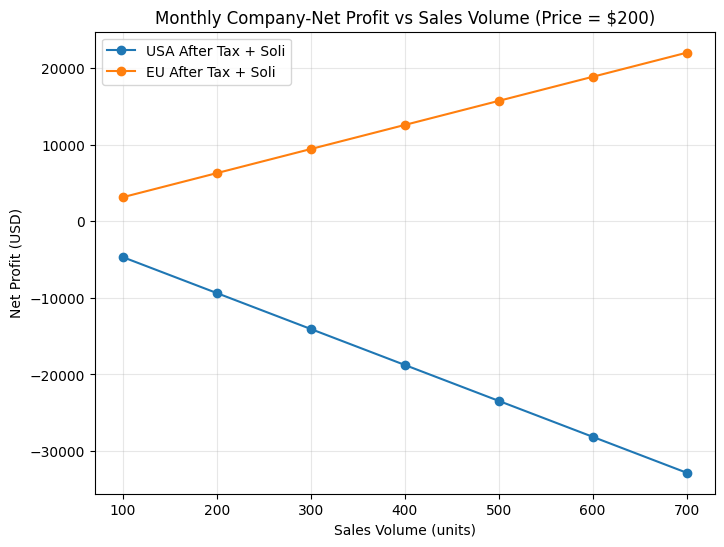

In [26]:
import matplotlib.pyplot as plt

# Component costs (USD)
parts = {"raspi": 20, "nfc": 3.5, "rfid": 5.0, "radio_freq_emmitter": 0.0, "case": 8.0, "keyboard": 5, "display": 7, "bluetooth": 1.8, "battery": 10, "misc_parts": 5.0}
production = {"assembly_and_quality_china": 12.0}
shipping_logistics = {"transfer_to_producer": 2.0, "air_freight": 4.5}
additional_costs = {"packaging": 2, "warranty_reserve": 3.0, "customer_support": 2.5, "returns_handling": 1.5}

# Tariffs
tariffs = {"china_eu": 0.175, "china_usa": 1}

# Tax rates (Germany)
koerperschaftssteuer = 0.15
gewerbesteuerhebesatz = 4.3
gewerbesteuermessbetrag = 0.035
trade_tax_rate = gewerbesteuerhebesatz * gewerbesteuermessbetrag
solidarity_surcharge = 0.055  

# Base manufacturing cost per unit
manufacturing_cost = (
    sum(parts.values())
    + min(production.values())
    + sum(shipping_logistics.values())
    + sum(additional_costs.values())
)

def calculate_tax_with_soli(profit):
    trade_tax = profit * trade_tax_rate
    corporate_tax = (profit - trade_tax) * koerperschaftssteuer
    soli = corporate_tax * solidarity_surcharge
    return trade_tax + corporate_tax + soli

# Prices from 130 to 190
price_points = range(130, 201, 10)
sales_volumes = [100, 200, 300, 400, 500, 600, 700]

for price in price_points:
    net_profit_usa = []
    net_profit_eu = []
    
    for vol in sales_volumes:
        # USA
        rev_usa = price * vol
        cost_usa = manufacturing_cost * (1 + tariffs["china_usa"]) * vol
        gross_usa = rev_usa - cost_usa
        net_usa = gross_usa - calculate_tax_with_soli(gross_usa)
        net_profit_usa.append(net_usa)
        
        # EU
        rev_eu = price * vol
        cost_eu = manufacturing_cost * (1 + tariffs["china_eu"]) * vol
        gross_eu = rev_eu - cost_eu
        net_eu = gross_eu - calculate_tax_with_soli(gross_eu)
        net_profit_eu.append(net_eu)
    
    plt.figure(figsize=(8, 6))
    plt.plot(sales_volumes, net_profit_usa, marker='o', label='USA After Tax + Soli')
    plt.plot(sales_volumes, net_profit_eu, marker='o', label='EU After Tax + Soli')
    plt.title(f'Monthly Company-Net Profit vs Sales Volume (Price = ${price})')
    plt.xlabel('Sales Volume (units)')
    plt.ylabel('Net Profit (USD)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

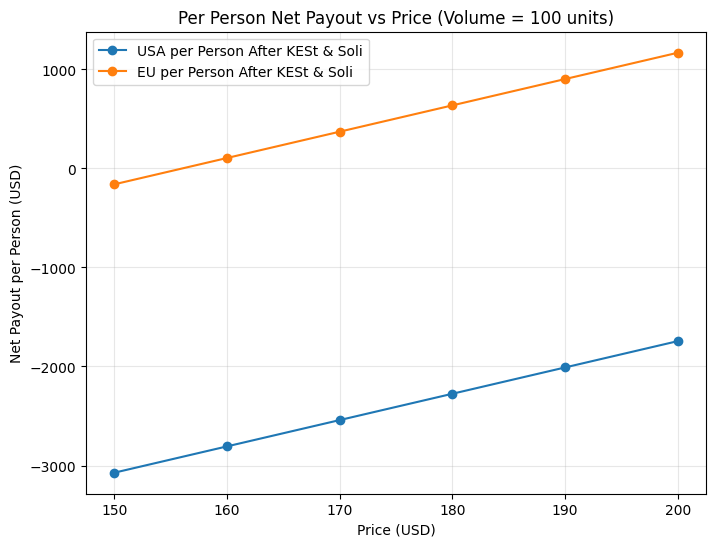

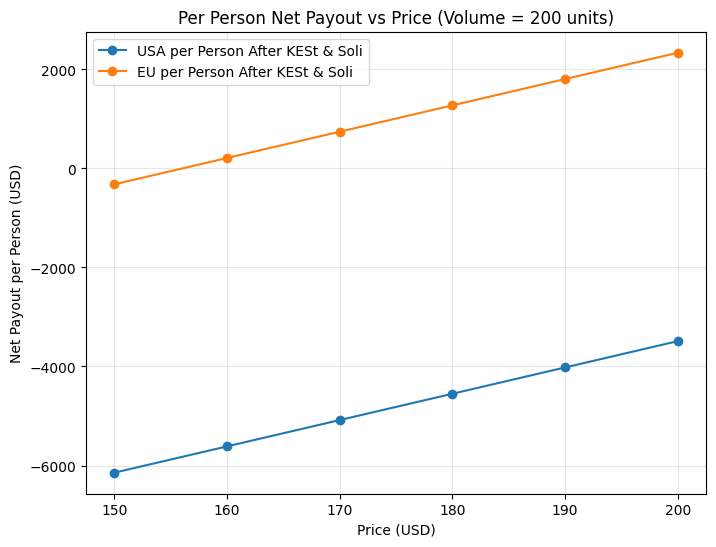

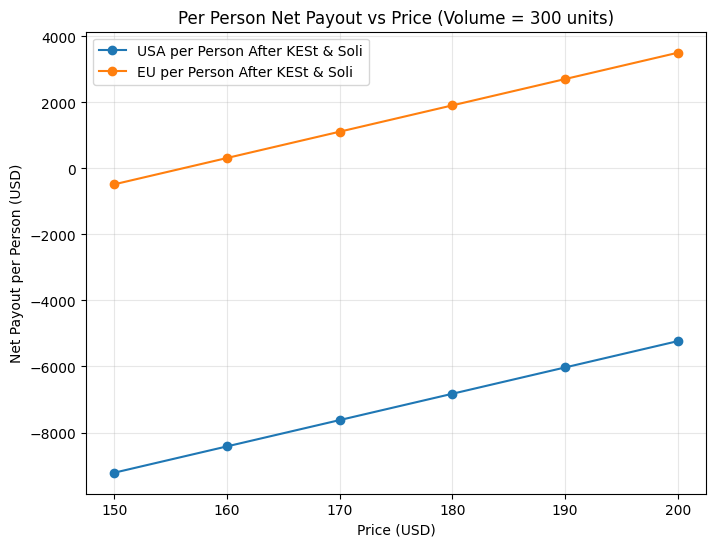

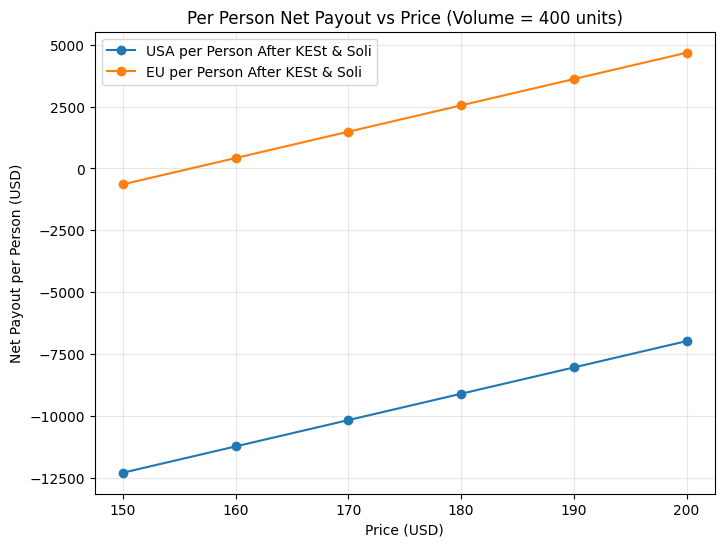

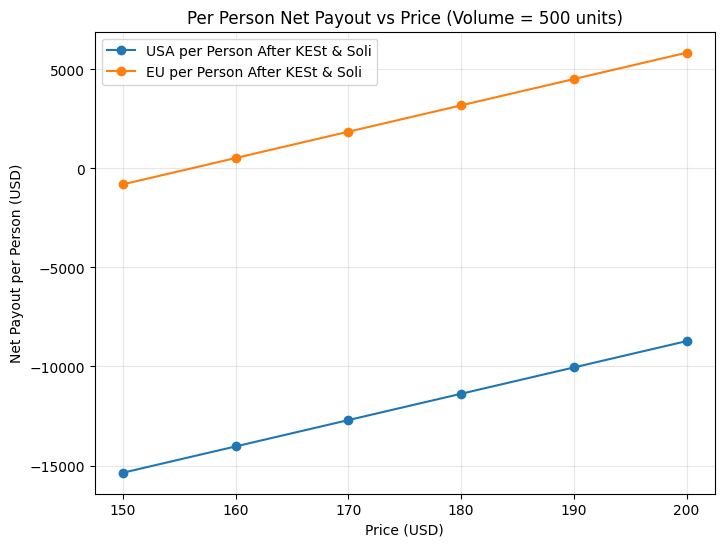

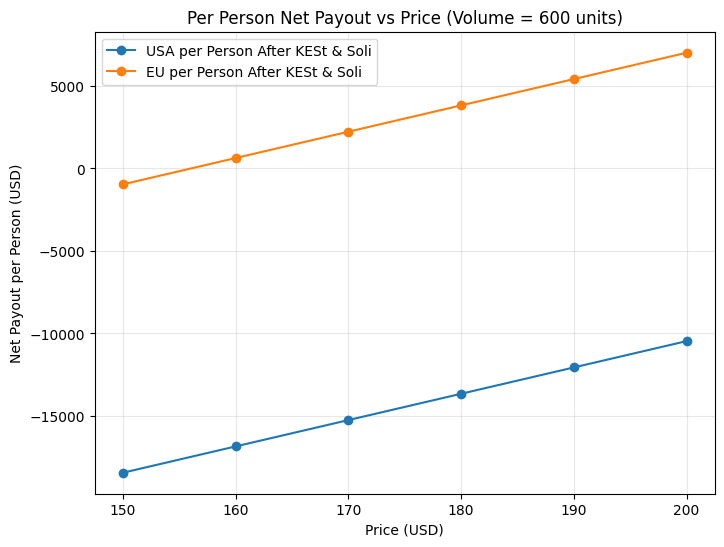

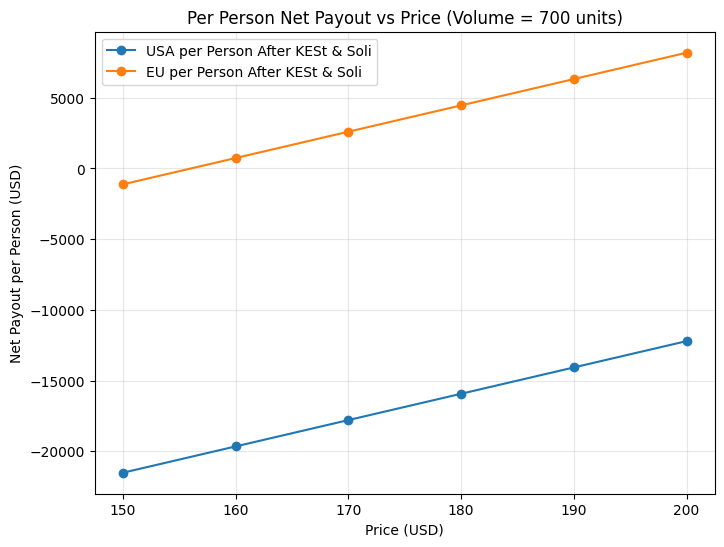

In [29]:
# Kapitalertragssteuer + Solidaritätszuschlag
kest_rate = 0.25 * (1 + 0.055)

# Base manufacturing cost per unit
manufacturing_cost = (
    sum(parts.values())
    + min(production.values())
    + sum(shipping_logistics.values())
    + sum(additional_costs.values())
)

def calculate_tax(profit):
    trade_tax = profit * trade_tax_rate
    corporate_tax = (profit - trade_tax) * koerperschaftssteuer
    return trade_tax + corporate_tax

price_points = list(range(150, 201, 10))
sales_volumes = [100, 200, 300, 400, 500, 600, 700]

# per-person payout after taxes for each volume
for vol in sales_volumes:
    per_person_usa = []
    per_person_eu = []
    for price in price_points:
        # USA net profit
        rev_usa = price * vol
        cost_usa = manufacturing_cost * (1 + tariffs["china_usa"]) * vol
        gross_usa = rev_usa - cost_usa
        net_usa = gross_usa - calculate_tax(gross_usa)
        # After KESt & Soli, split between two
        per_person_usa.append((net_usa * (1 - kest_rate)) / 2)

        # EU net profit
        rev_eu = price * vol
        cost_eu = manufacturing_cost * (1 + tariffs["china_eu"]) * vol
        gross_eu = rev_eu - cost_eu
        net_eu = gross_eu - calculate_tax(gross_eu)
        per_person_eu.append((net_eu * (1 - kest_rate)) / 2)

    # Plot for this sales volume
    plt.figure(figsize=(8, 6))
    plt.plot(price_points, per_person_usa, marker='o', label='USA per Person After KESt & Soli')
    plt.plot(price_points, per_person_eu, marker='o', label='EU per Person After KESt & Soli')
    plt.title(f'Per Person Net Payout vs Price (Volume = {vol} units)')
    plt.xlabel('Price (USD)')
    plt.ylabel('Net Payout per Person (USD)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

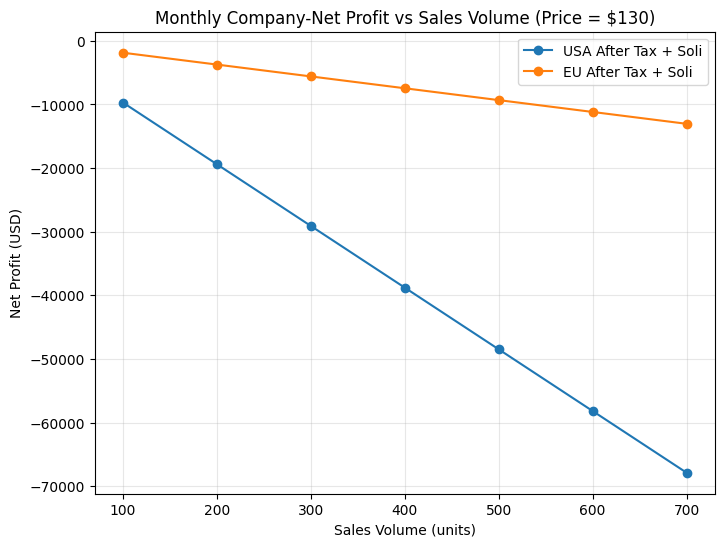

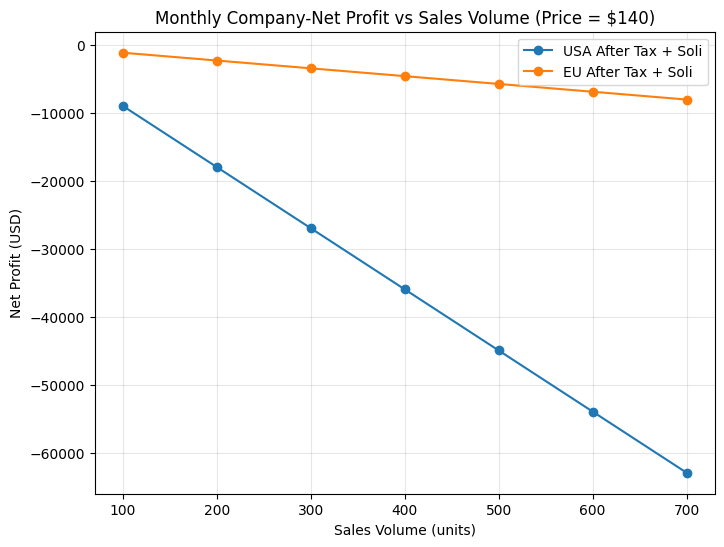

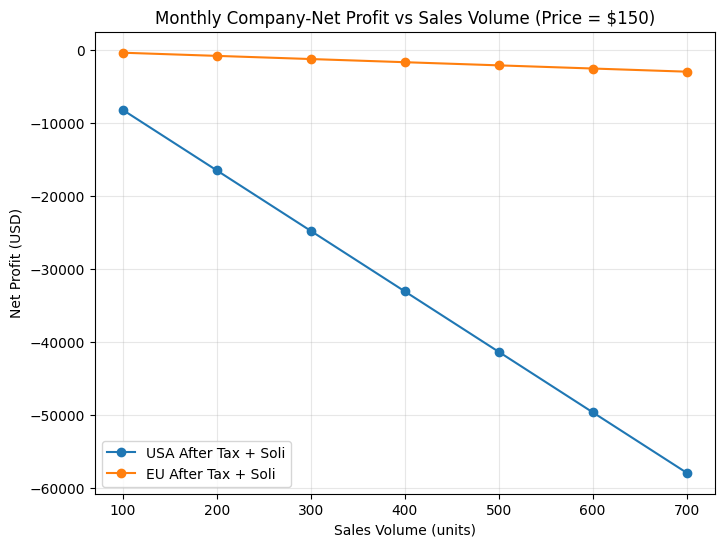

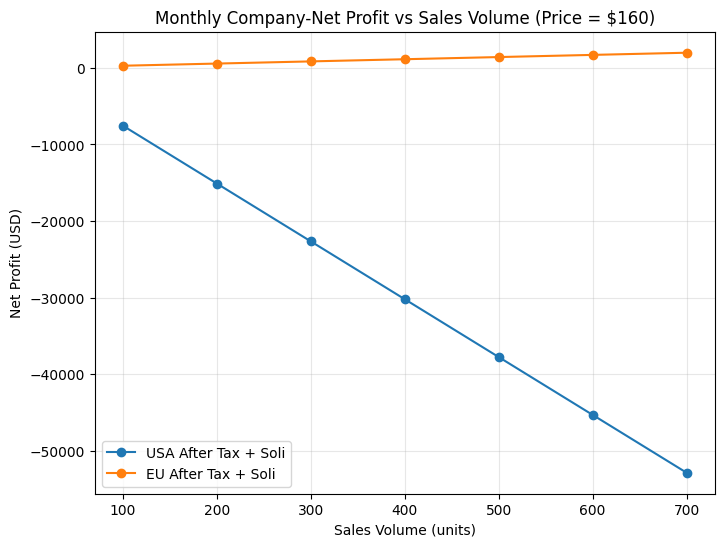

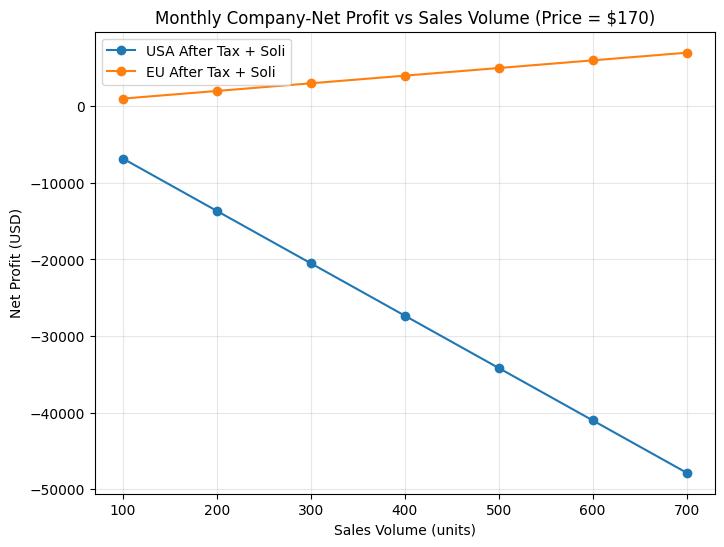

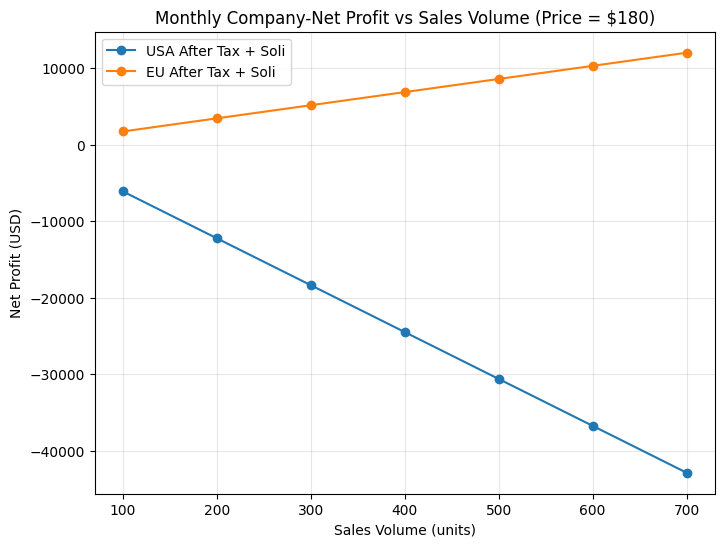

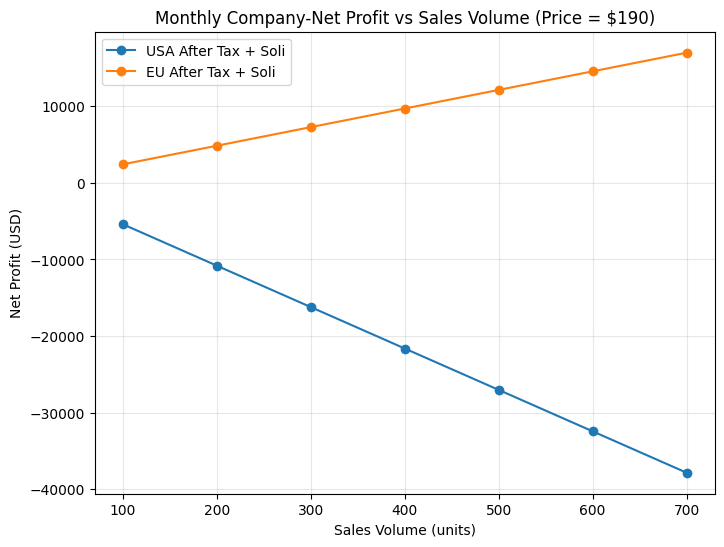

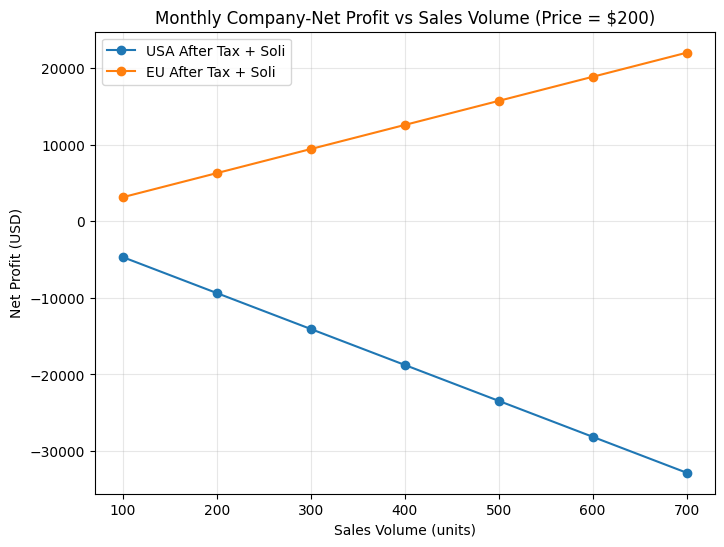

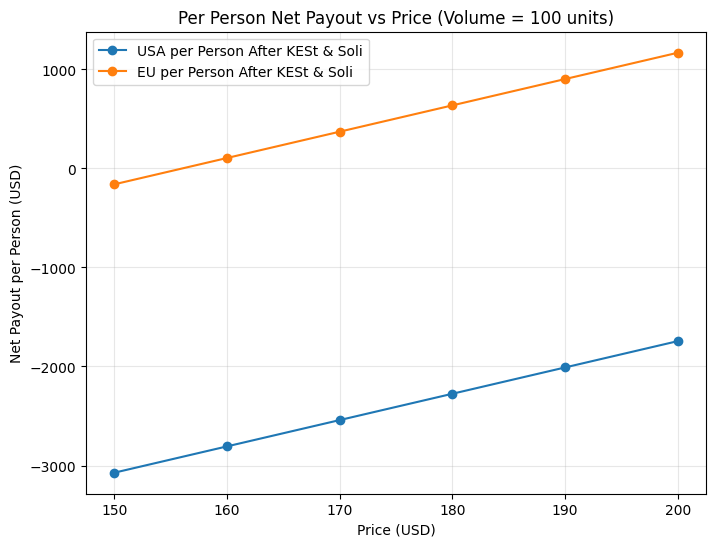

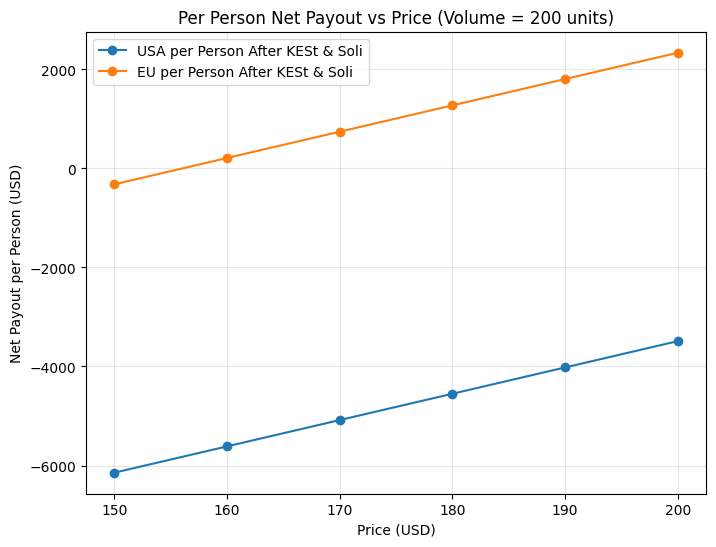

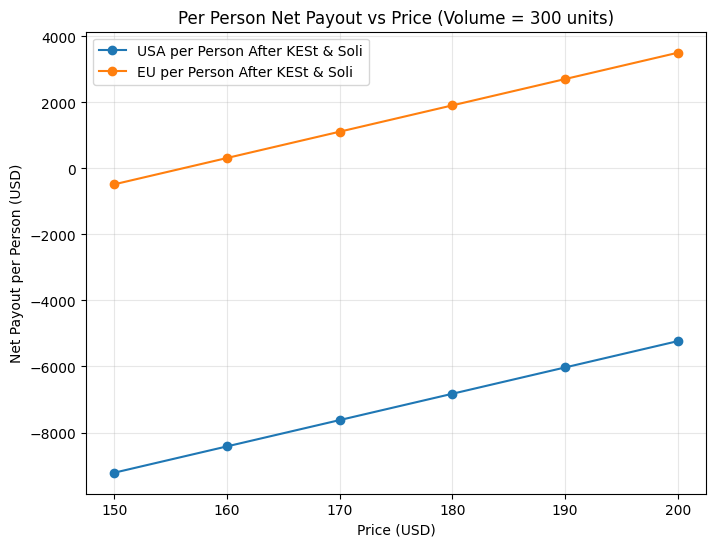

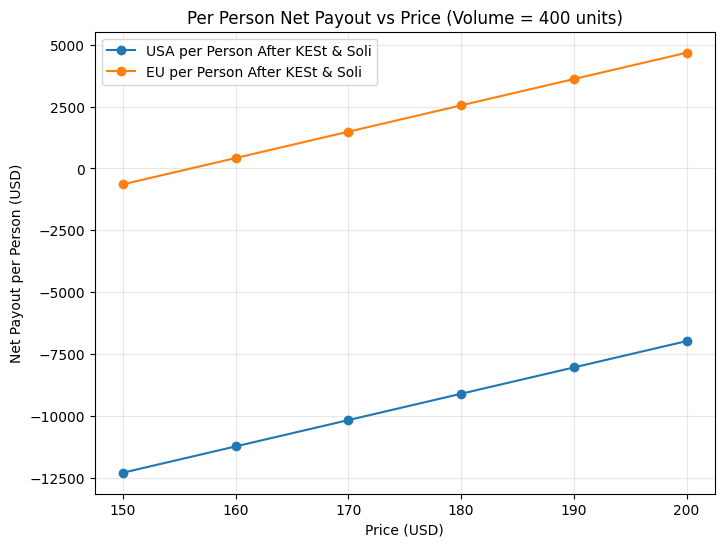

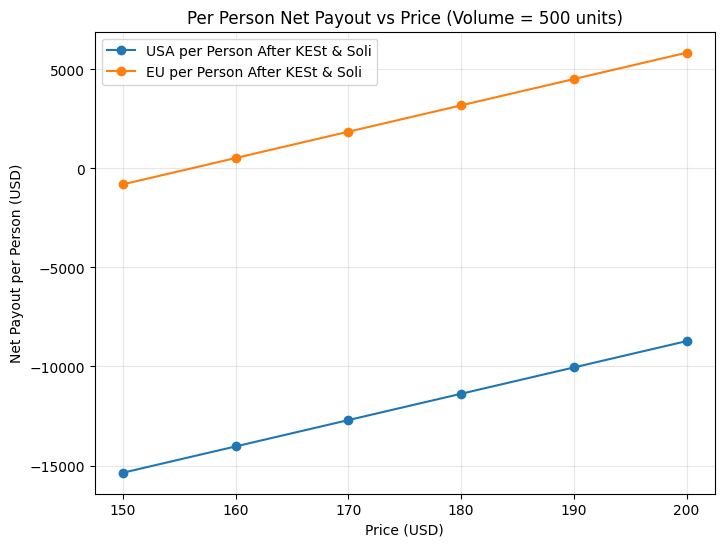

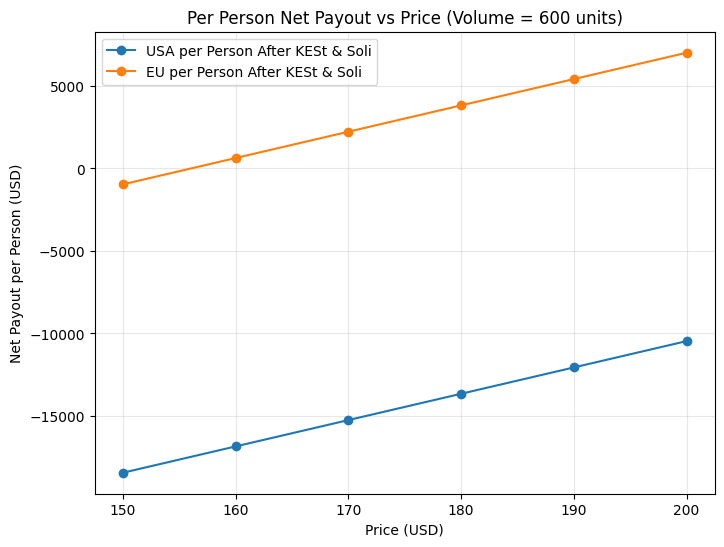

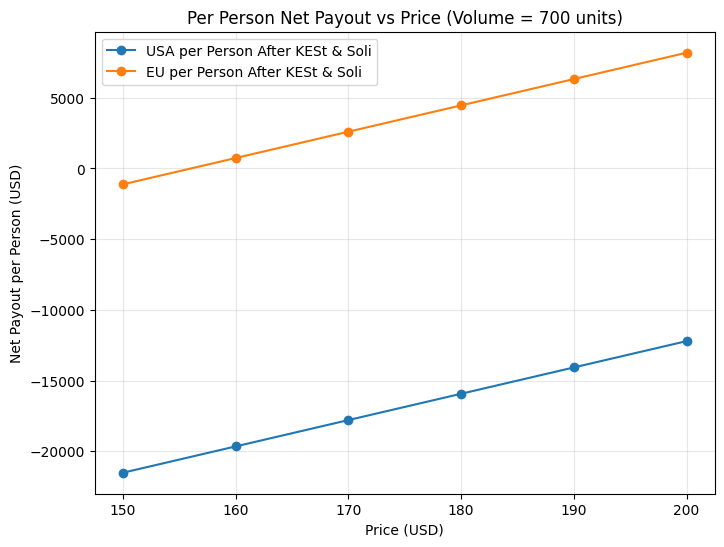

In [1]:
# Tax rates (Germany)
koerperschaftssteuer = 0.15
gewerbesteuerhebesatz = 4.3
gewerbesteuermessbetrag = 0.035
trade_tax_rate = gewerbesteuerhebesatz * gewerbesteuermessbetrag
solidarity_surcharge = 0.055  

# Base manufacturing cost per unit
manufacturing_cost = (
    sum(parts.values())
    + min(production.values())
    + sum(shipping_logistics.values())
    + sum(additional_costs.values())
)

def calculate_tax_with_soli(profit):
    trade_tax = profit * trade_tax_rate
    corporate_tax = (profit - trade_tax) * koerperschaftssteuer
    soli = corporate_tax * solidarity_surcharge
    return trade_tax + corporate_tax + soli

# Prices from 130 to 200
price_points = range(130, 201, 10)
sales_volumes = [100, 200, 300, 400, 500, 600, 700]

for price in price_points:
    net_profit_usa = []
    net_profit_eu = []
    
    for vol in sales_volumes:
        # USA
        rev_usa = price * vol
        cost_usa = manufacturing_cost * (1 + tariffs["china_usa"]) * vol
        gross_usa = rev_usa - cost_usa
        net_usa = gross_usa - calculate_tax_with_soli(gross_usa)
        net_profit_usa.append(net_usa)
        
        # EU
        rev_eu = price * vol
        cost_eu = manufacturing_cost * (1 + tariffs["china_eu"]) * vol
        gross_eu = rev_eu - cost_eu
        net_eu = gross_eu - calculate_tax_with_soli(gross_eu)
        net_profit_eu.append(net_eu)
    
    plt.figure(figsize=(8, 6))
    plt.plot(sales_volumes, net_profit_usa, marker='o', label='USA After Tax + Soli')
    plt.plot(sales_volumes, net_profit_eu, marker='o', label='EU After Tax + Soli')
    plt.title(f'Monthly Company-Net Profit vs Sales Volume (Price = ${price})')
    plt.xlabel('Sales Volume (units)')
    plt.ylabel('Net Profit (USD)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

# Kapitalertragssteuer + Solidaritätszuschlag
kest_rate = 0.25 * (1 + 0.055)

def calculate_tax(profit):
    trade_tax = profit * trade_tax_rate
    corporate_tax = (profit - trade_tax) * koerperschaftssteuer
    return trade_tax + corporate_tax

price_points = list(range(150, 201, 10))

for vol in sales_volumes:
    per_person_usa = []
    per_person_eu = []
    for price in price_points:
        # US net profit
        rev_usa = price * vol
        cost_usa = manufacturing_cost * (1 + tariffs["china_usa"]) * vol
        gross_usa = rev_usa - cost_usa
        net_usa = gross_usa - calculate_tax(gross_usa)
        # After KESt,Soli, split between two
        per_person_usa.append((net_usa * (1 - kest_rate)) / 2)

        # EU net profit
        rev_eu = price * vol
        cost_eu = manufacturing_cost * (1 + tariffs["china_eu"]) * vol
        gross_eu = rev_eu - cost_eu
        net_eu = gross_eu - calculate_tax(gross_eu)
        per_person_eu.append((net_eu * (1 - kest_rate)) / 2)

    plt.figure(figsize=(8, 6))
    plt.plot(price_points, per_person_usa, marker='o', label='USA per Person After KESt & Soli')
    plt.plot(price_points, per_person_eu, marker='o', label='EU per Person After KESt & Soli')
    plt.title(f'Per Person Net Payout vs Price (Volume = {vol} units)')
    plt.xlabel('Price (USD)')
    plt.ylabel('Net Payout per Person (USD)')
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


In [ ]:
fixed_costs = {
    "software_dev": 20000,
    "molds_for_case_parts": 5000,
    "insurance": 1000,
    "ce_certificate": 2000,     
    "us_certificate": 2000,
    "marketing": 5000
}